## Train ML Models

In [1]:
# required libraries
import os
import pickle
import torch
import torch.nn as nn
import math

import numpy as np
import pandas as pd

import data.processor as preprocess

import mlmodel.mlp as model_mlp
import mlmodel.softdt as model_softdt
import mlmodel.tab_transformer as model_tabtrans

processed_data_path = os.path.join(os.getcwd(), 'data/preprocessed/')
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [2]:
# ignore future warnings by pytorch
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Adult Dataset

In [17]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/adult')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([21112, 12]), y_train: torch.Size([21112])
X_val: torch.Size([3017, 12]), y_val: torch.Size([3017])
X_test: torch.Size([6033, 12]), y_test: torch.Size([6033])
The num of embedding dim for Transformer is: 10
The num of categorical features is: 7
The num of continues features is: 5
The num of total features is: 12
The embedding dims are: [4, 3, 3, 4, 3, 3, 7]
Combined embedding dims: [(16, 4), (7, 3), (7, 3), (14, 4), (6, 3), (5, 3), (41, 7)]


#### MLP

In [4]:
# define the model

config = {
    "model": "MLP",
    "dataset": "adult",
    "epochs": 150,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4, weight_decay=1e-4)



Training MLP on adult...


Training MLP:   0%|          | 0/150 [00:00<?, ?epoch/s]

Epoch 149: 100%|██████████| 150/150 [00:11<00:00, 13.57epoch/s, train_loss=0.327, train_accuracy=0.854, val_loss=0.33, val_accuracy=0.846] 


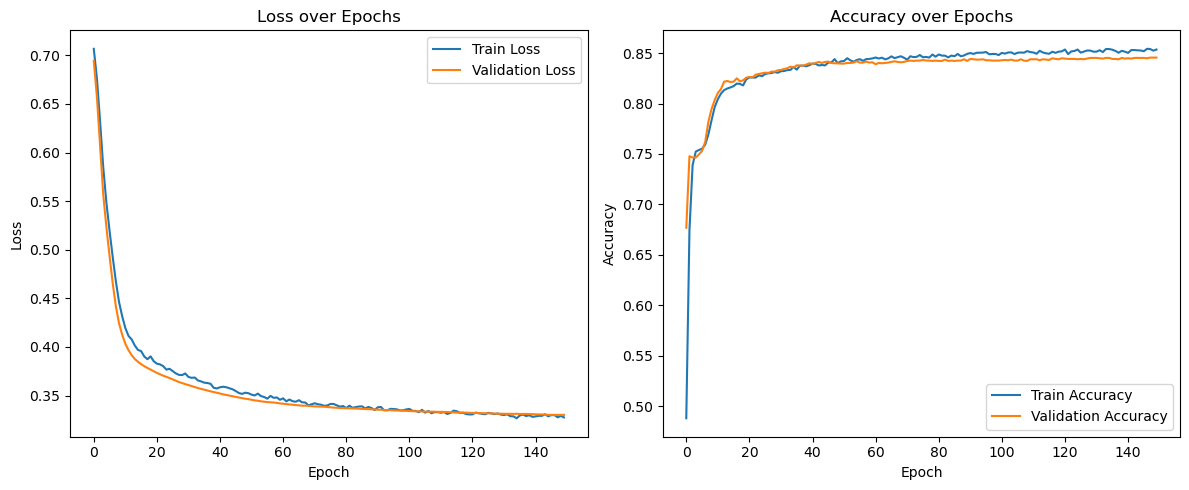

Model loaded from models/MLP_adult.pt


In [5]:
## Train
model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [6]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 85.38%


#### Soft Decision Tree

In [13]:
# define the model
config = {
    "model": "SoftDecisionTree",
    "dataset": "adult",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num, 
                                       output_dim=2, 
                                       depth=5, 
                                       lamda=0.01, 
                                       num_categorical=categorical_num,
                                       embedding_dims=embedding_dims,
                                       device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)


Training SoftDecisionTree on adult...


Epoch 99: 100%|██████████| 100/100 [00:39<00:00,  2.54epoch/s, train_loss=0.398, train_accuracy=0.855, val_loss=0.326, val_accuracy=0.852]


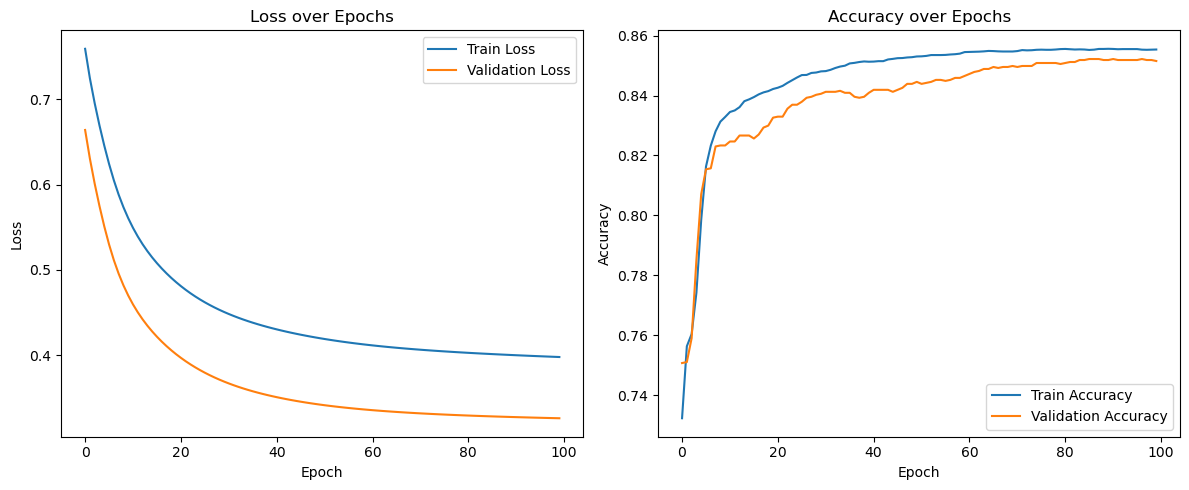

Model loaded from models/SoftDecisionTree_adult.pt


In [14]:
## Train
model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [15]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 85.63%


#### Tab Transformer

In [18]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "adult",
    "epochs": 10,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                      num_continuous=continues_num,
                                      dim=trans_dim,
                                      depth=3,
                                      heads=4,
                                      dim_head=16,
                                      dim_out=2,
                                      ff_dropout=0.2,
                                      attn_dropout=0.2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-3, weight_decay=1e-4)

In [21]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_adult.pt


In [22]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 83.77%


### Phishing URL


In [3]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/phishing_url')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([8001, 86]), y_train: torch.Size([8001])
X_val: torch.Size([1143, 86]), y_val: torch.Size([1143])
X_test: torch.Size([2286, 86]), y_test: torch.Size([2286])
The num of embedding dim for Transformer is: 2
The num of categorical features is: 1
The num of continues features is: 85
The num of total features is: 86
The embedding dims are: [2]
Combined embedding dims: [(3, 2)]


#### MLP

In [33]:
# define the model

config = {
    "model": "MLP",
    "dataset": "phishing_url",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'], 
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.2,
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4, weight_decay=1e-4)



Training MLP on phishing_url...


Epoch 99: 100%|██████████| 100/100 [00:02<00:00, 39.08epoch/s, train_loss=0.141, train_accuracy=0.954, val_loss=0.192, val_accuracy=0.946]


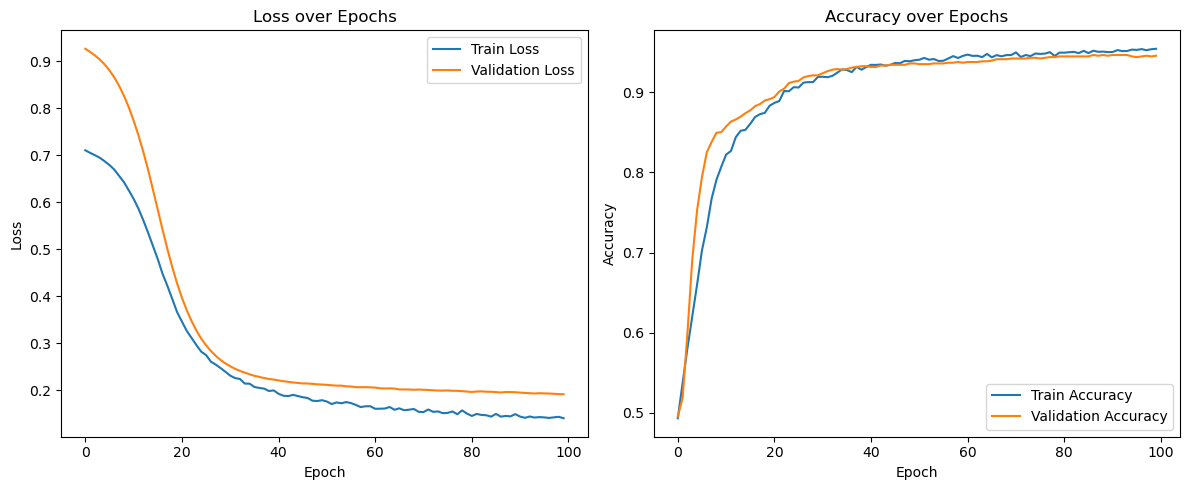

Model loaded from models/MLP_phishing_url.pt


In [34]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [35]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 96.15%


#### Soft Decision Tree

In [53]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "phishing_url",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)



Training SoftDecisionTree on phishing_url...


Epoch 99: 100%|██████████| 100/100 [00:17<00:00,  5.82epoch/s, train_loss=0.232, train_accuracy=0.969, val_loss=0.226, val_accuracy=0.943]


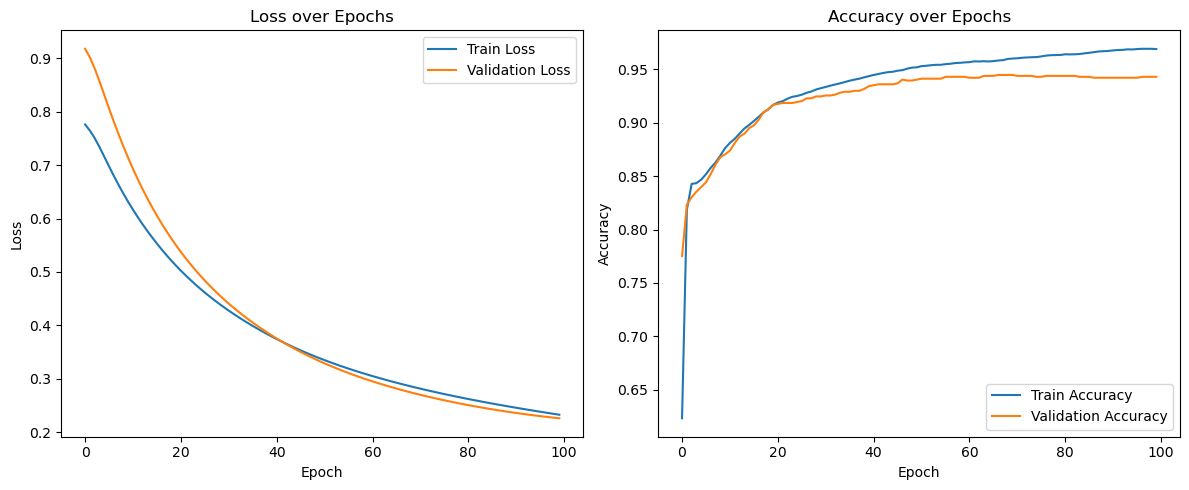

Model loaded from models/SoftDecisionTree_phishing_url.pt


In [54]:
## Train
model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [55]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 96.11%


#### Tab Transformer

In [8]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "phishing_url",
    "epochs": 50,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=3,
                                         heads=4,
                                         dim_head=8,
                                         dim_out=2,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

Training TabTransformer on phishing_url...


Epoch 49: 100%|██████████| 50/50 [00:11<00:00,  4.21epoch/s, train_loss=0.0762, train_accuracy=0.976, val_loss=0.178, val_accuracy=0.952]


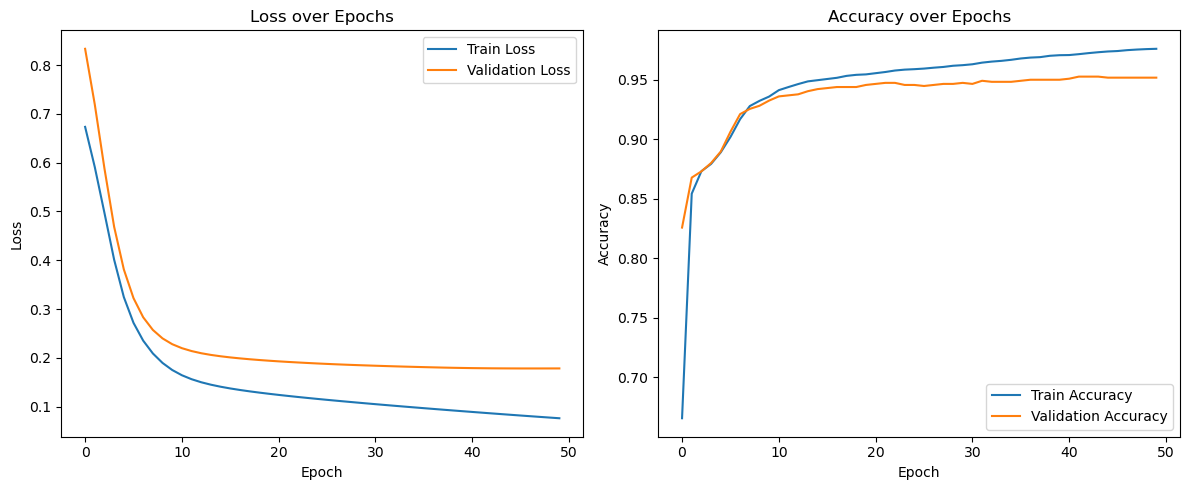

Model loaded from models/TabTransformer_phishing_url.pt


In [9]:
## Train
model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [11]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 96.68%


### PenDigit

In [3]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/pendigit')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for FTTransformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([7693, 16]), y_train: torch.Size([7693])
X_val: torch.Size([1100, 16]), y_val: torch.Size([1100])
X_test: torch.Size([2199, 16]), y_test: torch.Size([2199])
The num of embedding dim for FTTransformer is: 0
The num of categorical features is: 0
The num of continues features is: 16
The num of total features is: 16
The embedding dims are: []
Combined embedding dims: []


#### MLP

In [7]:
# define the model

config = {
    "model": "MLP",
    "dataset": "pendigit",
    "epochs": 200,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=10,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on pendigit...


Epoch 199: 100%|██████████| 200/200 [00:02<00:00, 74.99epoch/s, train_loss=0.205, train_accuracy=0.939, val_loss=0.439, val_accuracy=0.975]


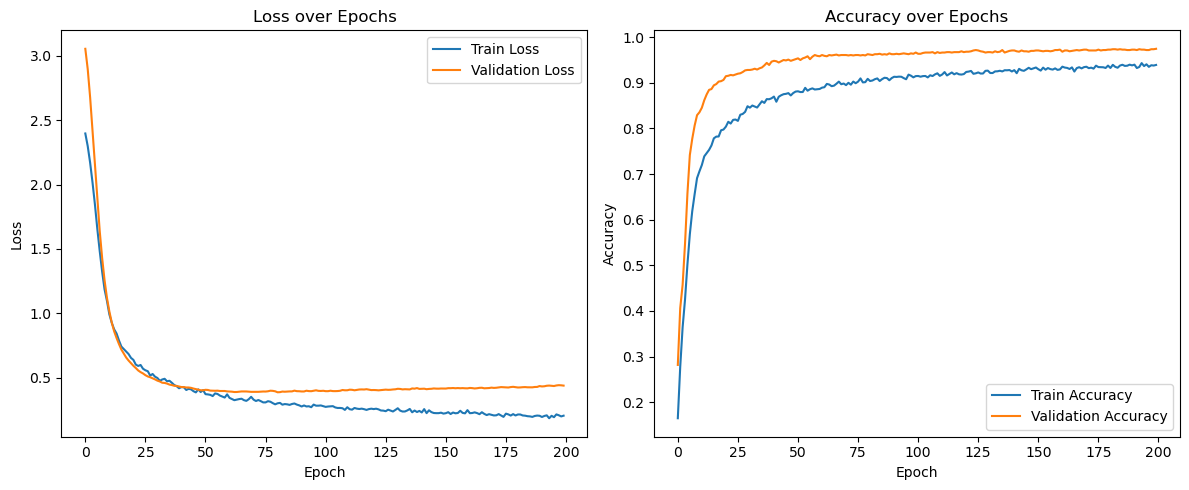

Model loaded from models/MLP_pendigit.pt


In [8]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [9]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 97.95%


#### Soft Decision Tree

In [114]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "pendigit",
    "epochs": 250,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=10,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)


Training SoftDecisionTree on pendigit...


Epoch 249: 100%|██████████| 250/250 [00:39<00:00,  6.38epoch/s, train_loss=0.249, train_accuracy=0.98, val_loss=0.315, val_accuracy=0.967] 


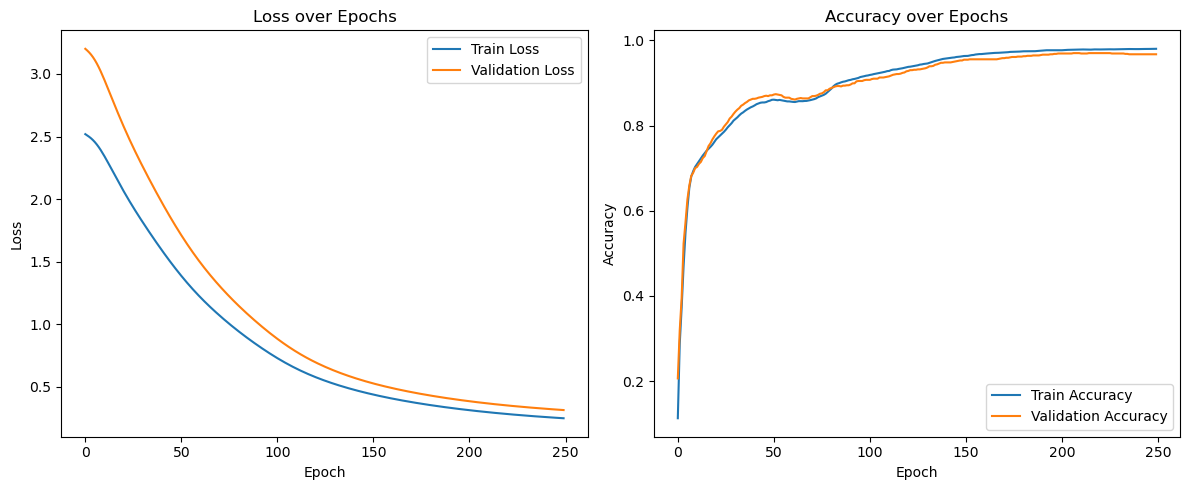

Model loaded from models/SoftDecisionTree_pendigit.pt


In [115]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [116]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 97.73%


#### Tab Transformer

In [12]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "pendigit",
    "epochs": 250,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=3,
                                         heads=4,
                                         dim_head=8,
                                         dim_out=10,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

In [13]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_pendigit.pt


In [14]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 98.04%


### Mushroom

In [6]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/mushroom')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([3950, 22]), y_train: torch.Size([3950])
X_val: torch.Size([565, 22]), y_val: torch.Size([565])
X_test: torch.Size([1129, 22]), y_test: torch.Size([1129])
The num of embedding dim for Transformer is: 10
The num of categorical features is: 18
The num of continues features is: 4
The num of total features is: 22
The embedding dims are: [3, 2, 3, 3, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3]
Combined embedding dims: [(6, 3), (4, 2), (8, 3), (7, 3), (2, 2), (2, 2), (9, 3), (4, 2), (4, 2), (4, 2), (7, 3), (7, 3), (2, 2), (3, 2), (4, 2), (6, 3), (6, 3), (6, 3)]


#### MLP

In [14]:
# define the model

config = {
    "model": "MLP",
    "dataset": "mushroom",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.4
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on mushroom...


Epoch 49: 100%|██████████| 50/50 [00:01<00:00, 43.16epoch/s, train_loss=0.00605, train_accuracy=0.999, val_loss=4e-5, val_accuracy=1]      


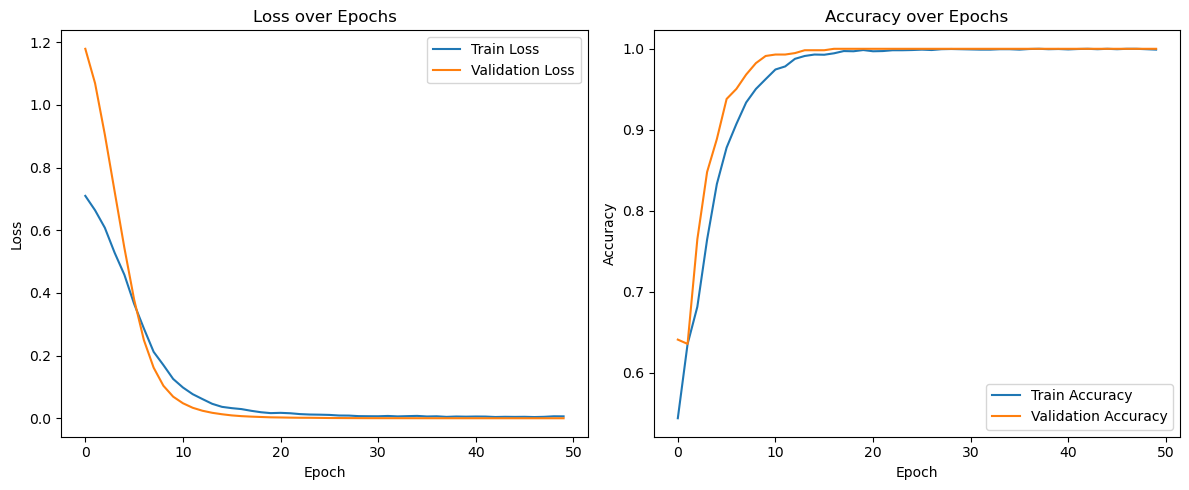

Model loaded from models/MLP_mushroom.pt


In [15]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [9]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 100.00%


#### Soft Decision Tree

In [10]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "mushroom",
    "epochs": 75,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)


Training SoftDecisionTree on mushroom...


Epoch 74: 100%|██████████| 75/75 [00:04<00:00, 15.30epoch/s, train_loss=0.296, train_accuracy=0.998, val_loss=0.313, val_accuracy=1]    


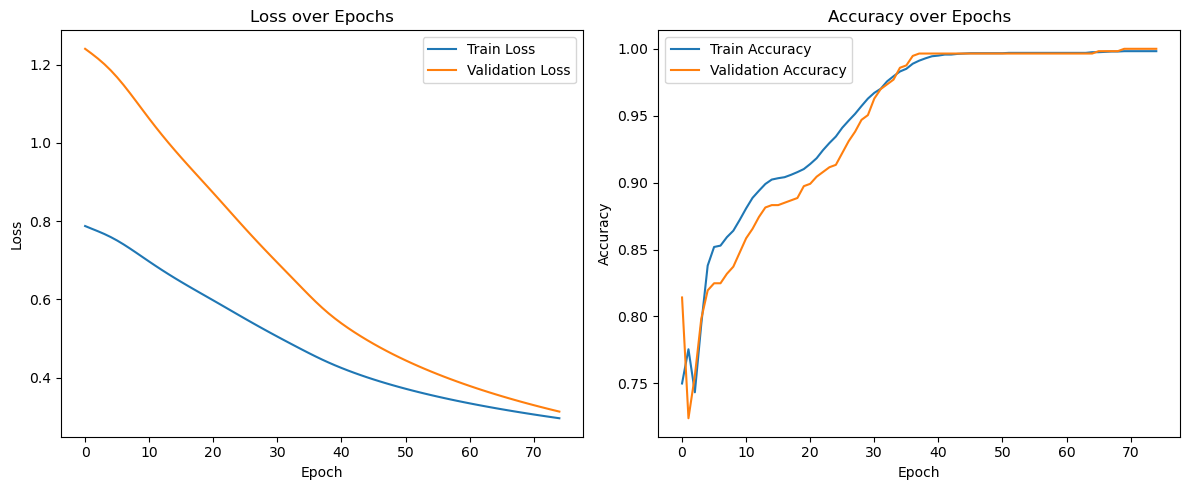

Model loaded from models/SoftDecisionTree_mushroom.pt


In [11]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [12]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 99.91%


#### Tab Transformer

In [9]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "mushroom",
    "epochs": 10,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=3,
                                         heads=4,
                                         dim_head=8,
                                         dim_out=2,
                                         ff_dropout=0.2,
                                         attn_dropout=0.2,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

Training TabTransformer on mushroom...


Epoch 9: 100%|██████████| 10/10 [00:16<00:00,  1.61s/epoch, train_loss=0.0132, train_accuracy=0.997, val_loss=0.0131, val_accuracy=0.998]


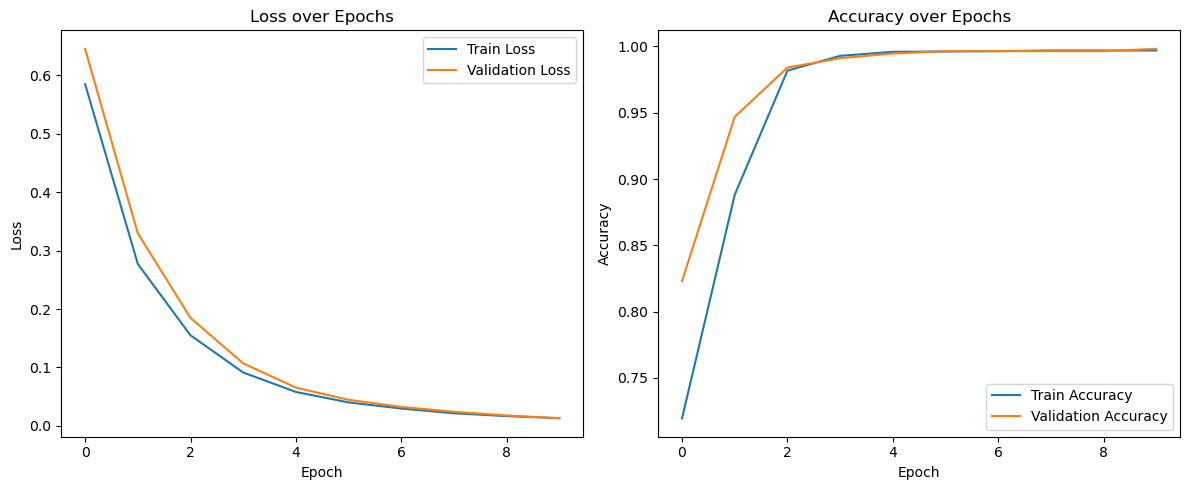

Model loaded from models/TabTransformer_mushroom.pt


In [10]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [11]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 99.82%


### MiniBooNE

In [8]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/MiniBooNE')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for FTTransformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([91044, 50]), y_train: torch.Size([91044])
X_val: torch.Size([13007, 50]), y_val: torch.Size([13007])
X_test: torch.Size([26013, 50]), y_test: torch.Size([26013])
The num of embedding dim for FTTransformer is: 0
The num of categorical features is: 0
The num of continues features is: 50
The num of total features is: 50
The embedding dims are: []
Combined embedding dims: []


#### MLP

In [16]:
# define the model

config = {
    "model": "MLP",
    "dataset": "MiniBooNE",
    "epochs": 75,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on MiniBooNE...


Epoch 74: 100%|██████████| 75/75 [00:32<00:00,  2.31epoch/s, train_loss=0.172, train_accuracy=0.933, val_loss=0.169, val_accuracy=0.935]


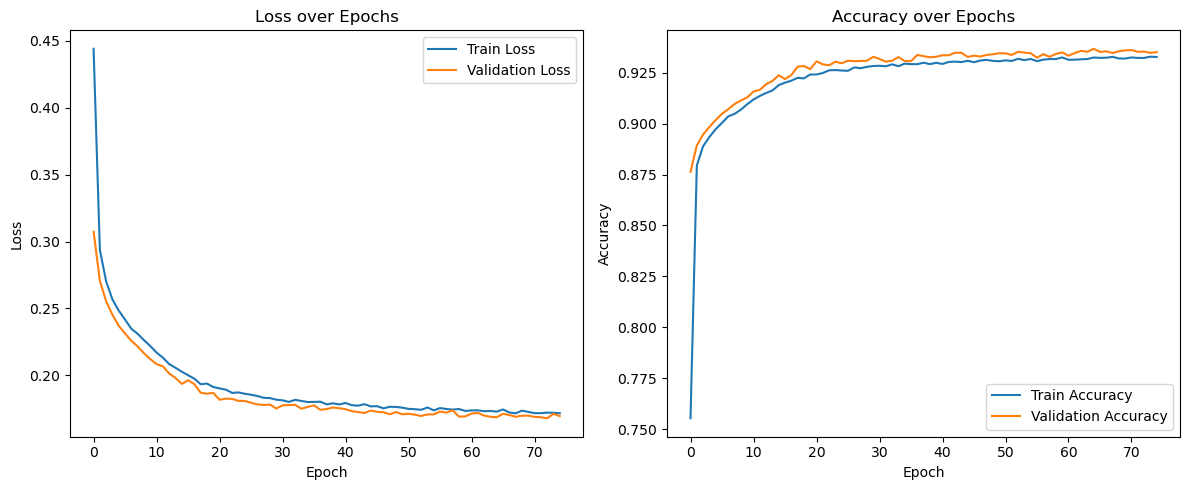

Model loaded from models/MLP_MiniBooNE.pt


In [17]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [18]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 93.59%


#### Soft Decision Tree

In [42]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "MiniBooNE",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-2, weight_decay=1e-4)


Training SoftDecisionTree on MiniBooNE...


Epoch 49: 100%|██████████| 50/50 [01:29<00:00,  1.79s/epoch, train_loss=0.292, train_accuracy=0.908, val_loss=0.229, val_accuracy=0.906]


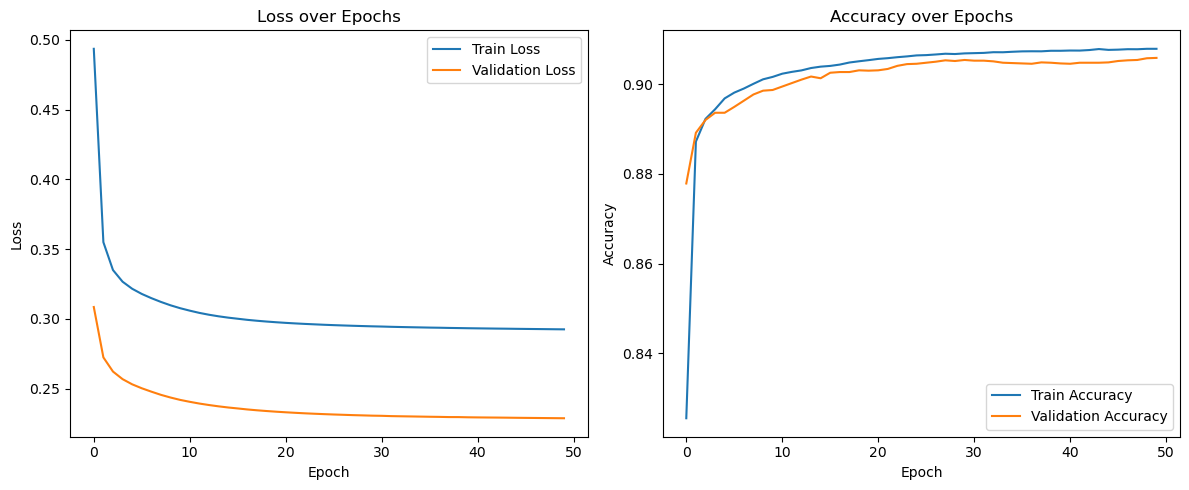

Model loaded from models/SoftDecisionTree_MiniBooNE.pt


In [43]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [44]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 90.79%


#### Tab Transformer

In [47]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "MiniBooNE",
    "epochs": 100,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=4,
                                         heads=5,
                                         dim_head=10,
                                         dim_out=2,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

Training TabTransformer on MiniBooNE...


Epoch 99: 100%|██████████| 100/100 [01:09<00:00,  1.44epoch/s, train_loss=0.154, train_accuracy=0.938, val_loss=0.172, val_accuracy=0.935]


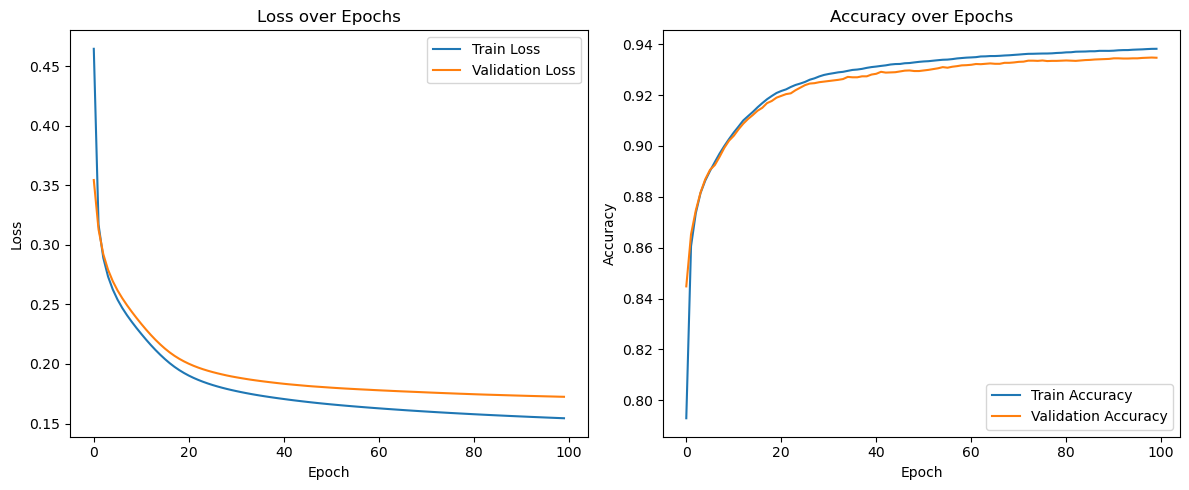

Model loaded from models/TabTransformer_MiniBooNE.pt


In [48]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [49]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 93.16%


### german_credit

In [171]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/german_credit')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for FTTransformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([700, 19]), y_train: torch.Size([700])
X_val: torch.Size([100, 19]), y_val: torch.Size([100])
X_test: torch.Size([200, 19]), y_test: torch.Size([200])
The num of embedding dim for FTTransformer is: 8
The num of categorical features is: 11
The num of continues features is: 8
The num of total features is: 19
The embedding dims are: [2, 3, 4, 3, 3, 2, 2, 2, 2, 2, 2]
Combined embedding dims: [(4, 2), (5, 3), (10, 4), (5, 3), (5, 3), (4, 2), (3, 2), (4, 2), (3, 2), (3, 2), (4, 2)]


#### MLP

In [172]:
# define the model

config = {
    "model": "MLP",
    "dataset": "german_credit",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on german_credit...


Epoch 49: 100%|██████████| 50/50 [00:00<00:00, 165.20epoch/s, train_loss=0.698, train_accuracy=0.754, val_loss=2.56, val_accuracy=0.79]


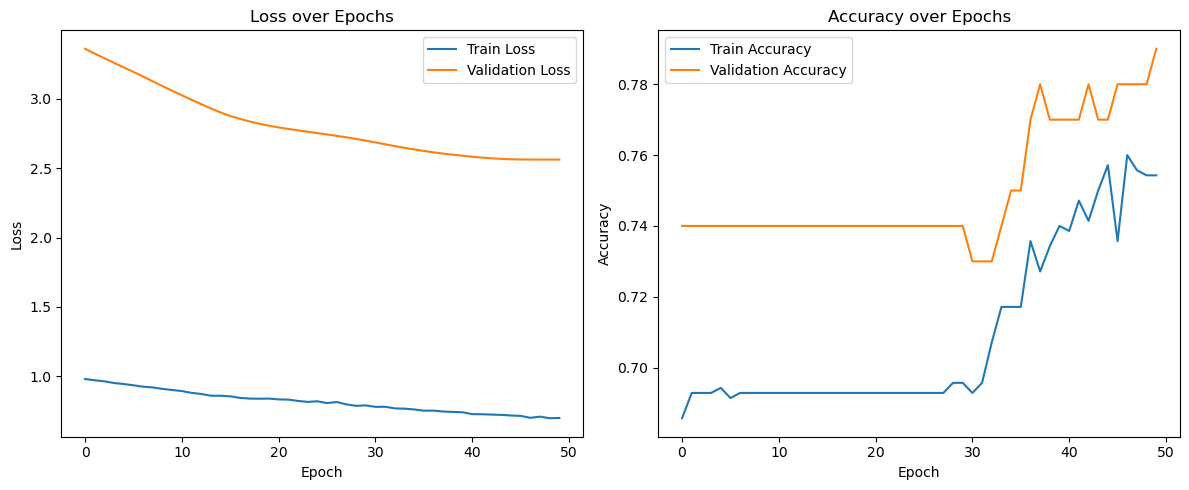

Model loaded from models/MLP_german_credit.pt


In [173]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [174]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 76.00%


#### Soft Decision Tree

In [118]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "german_credit",
    "epochs": 30,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-2, weight_decay=1e-4)


Training SoftDecisionTree on german_credit...


Epoch 29: 100%|██████████| 30/30 [00:00<00:00, 45.25epoch/s, train_loss=0.817, train_accuracy=0.78, val_loss=2.63, val_accuracy=0.75] 


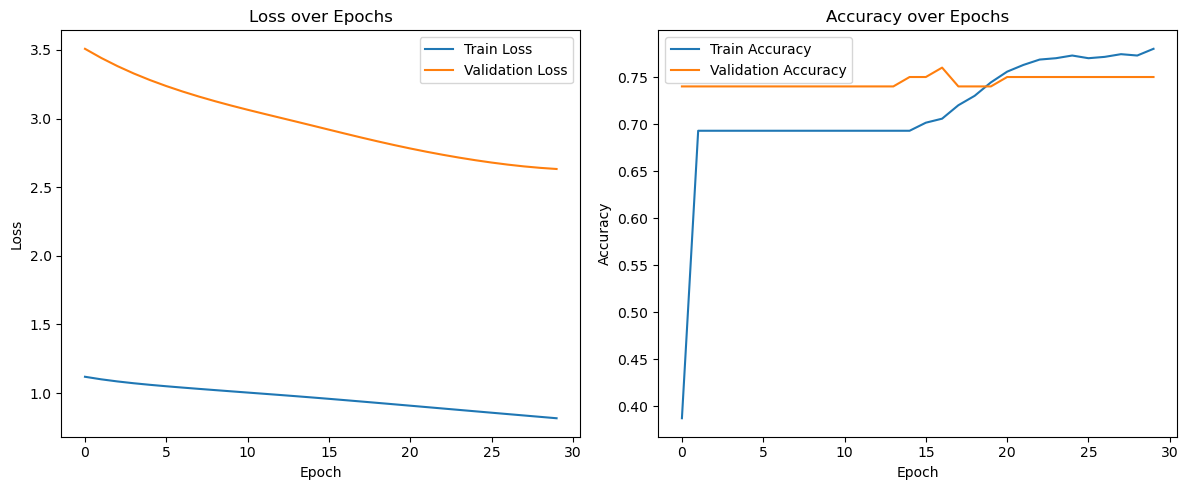

Model loaded from models/SoftDecisionTree_german_credit.pt


In [119]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [120]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 76.50%


#### Tab Transformer

In [175]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "german_credit",
    "epochs": 10,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=2,
                                         heads=3,
                                         dim_head=5,
                                         dim_out=2,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-2, weight_decay=1e-4)

Training TabTransformer on german_credit...


Epoch 9: 100%|██████████| 10/10 [00:01<00:00,  6.15epoch/s, train_loss=0.594, train_accuracy=0.811, val_loss=2.96, val_accuracy=0.73]


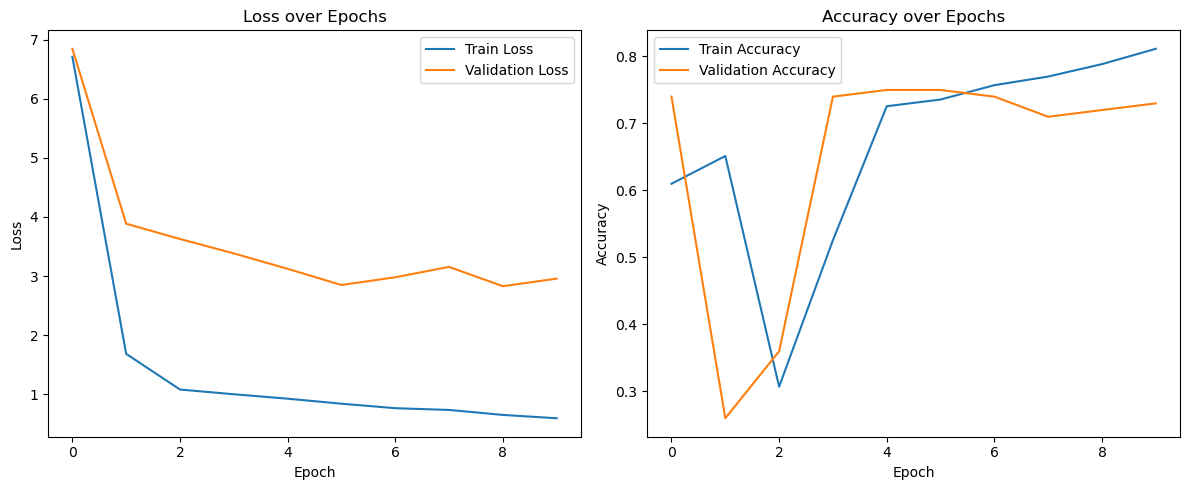

Model loaded from models/TabTransformer_german_credit.pt


In [176]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [177]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 75.50%


### electricity

In [178]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/electricity')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for FTTransformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([31717, 8]), y_train: torch.Size([31717])
X_val: torch.Size([4532, 8]), y_val: torch.Size([4532])
X_test: torch.Size([9063, 8]), y_test: torch.Size([9063])
The num of embedding dim for FTTransformer is: 3
The num of categorical features is: 1
The num of continues features is: 7
The num of total features is: 8
The embedding dims are: [3]
Combined embedding dims: [(7, 3)]


#### MLP

In [154]:
# define the model

config = {
    "model": "MLP",
    "dataset": "electricity",
    "epochs": 200,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on electricity...


Epoch 199: 100%|██████████| 200/200 [00:12<00:00, 15.54epoch/s, train_loss=0.424, train_accuracy=0.806, val_loss=0.428, val_accuracy=0.81] 


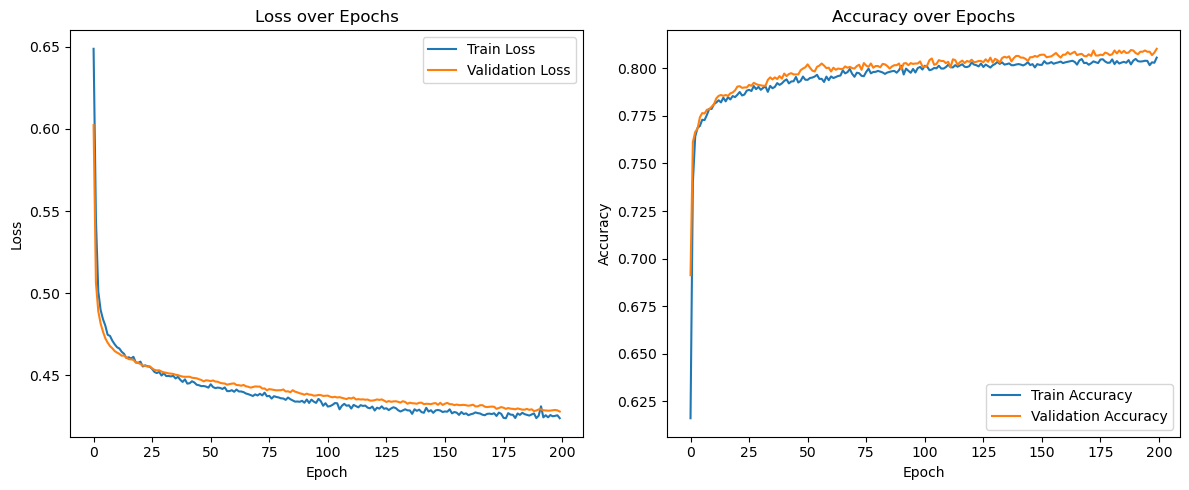

Model loaded from models/MLP_electricity.pt


In [155]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [156]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 81.11%


#### Soft Decision Tree

In [157]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "electricity",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-2, weight_decay=1e-4)


Training SoftDecisionTree on electricity...


Epoch 99: 100%|██████████| 100/100 [00:56<00:00,  1.76epoch/s, train_loss=0.488, train_accuracy=0.808, val_loss=0.428, val_accuracy=0.809]


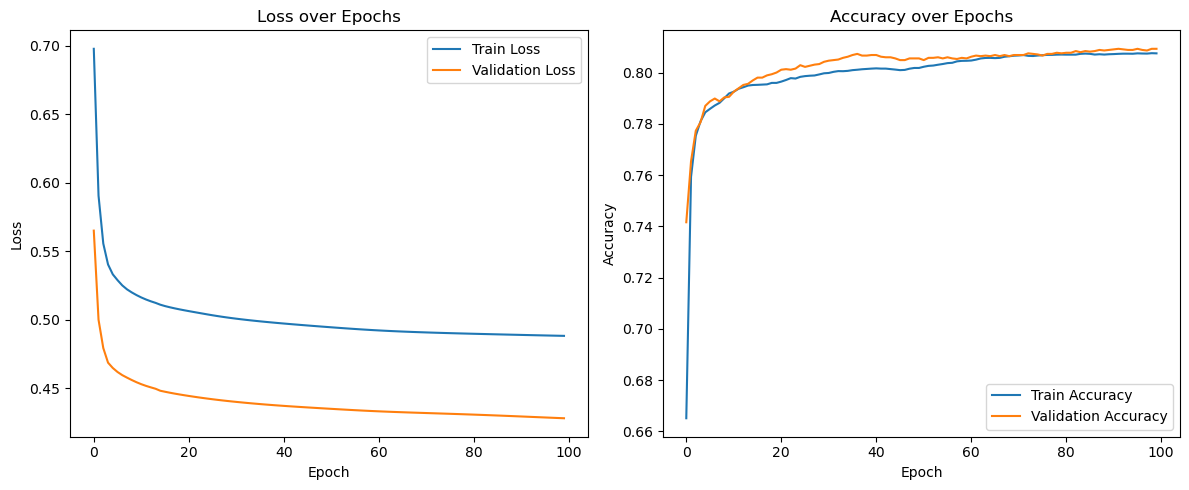

Model loaded from models/SoftDecisionTree_electricity.pt


In [158]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [159]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 81.14%


#### Tab Transformer

In [179]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "electricity",
    "epochs": 100,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=2,
                                         heads=3,
                                         dim_head=4,
                                         dim_out=2,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-3, weight_decay=1e-4)

Training TabTransformer on electricity...


Epoch 99: 100%|██████████| 100/100 [00:53<00:00,  1.86epoch/s, train_loss=0.423, train_accuracy=0.805, val_loss=0.443, val_accuracy=0.799]


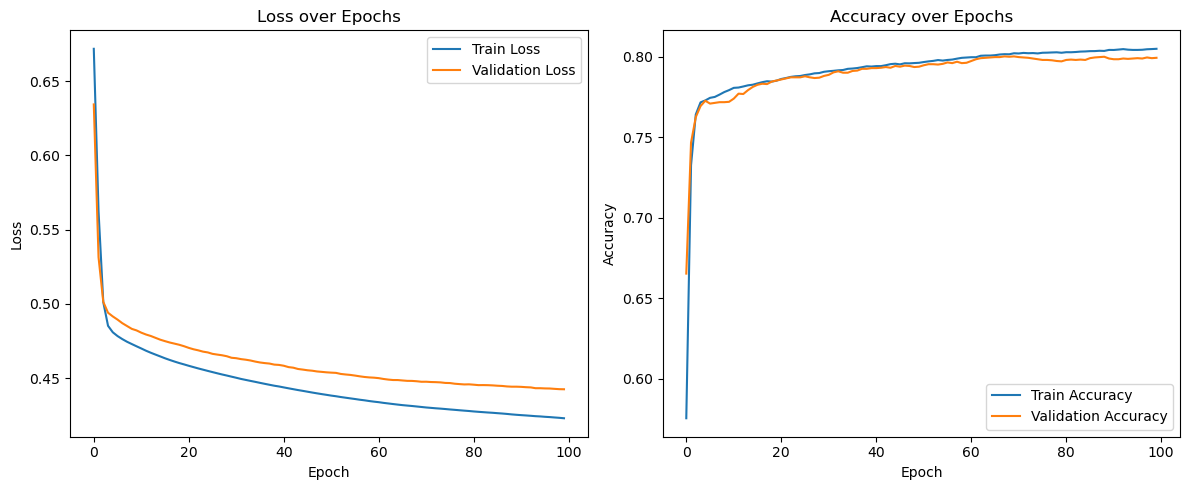

Model loaded from models/TabTransformer_electricity.pt


In [180]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [181]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 80.14%


### covertype

In [3]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/covertype')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = feature_nums['x_cat']
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for FTTransformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The embedding dims are: {embedding_dims}')

# List of (num_categories, embedding_dim)
embedding_dims = [(categories[i], embedding_dims[i]) for i in range(categorical_num)]
print(f"Combined embedding dims: {embedding_dims}")

Loaded data shapes:
X_train: torch.Size([406707, 54]), y_train: torch.Size([406707])
X_val: torch.Size([58102, 54]), y_val: torch.Size([58102])
X_test: torch.Size([116203, 54]), y_test: torch.Size([116203])
The num of embedding dim for FTTransformer is: 0
The num of categorical features is: 0
The num of continues features is: 54
The num of total features is: 54
The embedding dims are: []
Combined embedding dims: []


#### MLP

In [43]:
# define the model

config = {
    "model": "MLP",
    "dataset": "covertype",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=7,
                    num_categorical=categorical_num,
                    embedding_dims=embedding_dims,
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)



Training MLP on covertype...


Epoch 49: 100%|██████████| 50/50 [01:46<00:00,  2.14s/epoch, train_loss=0.453, train_accuracy=0.81, val_loss=0.389, val_accuracy=0.836] 


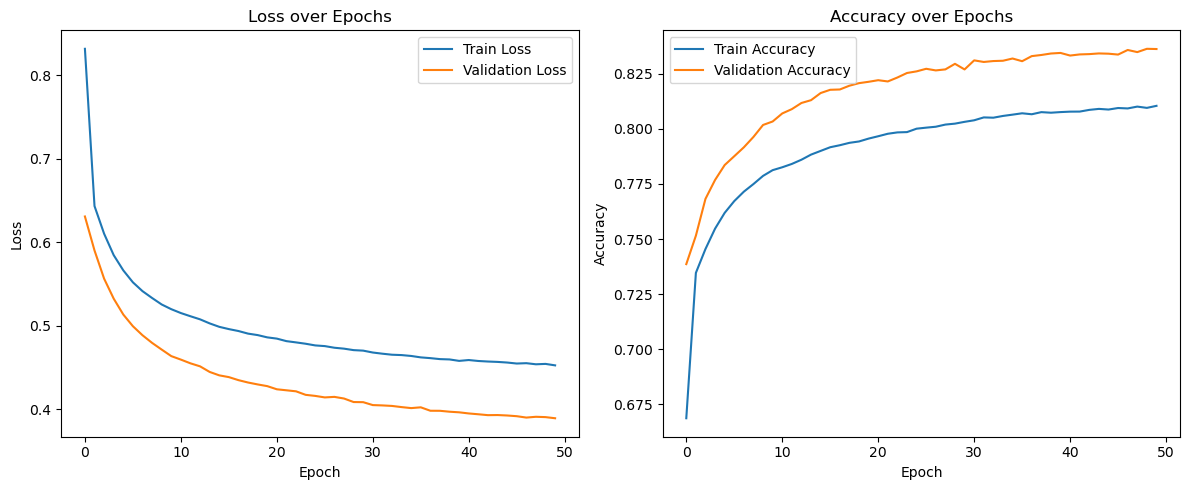

Model loaded from models/MLP_covertype.pt


In [44]:
## Train
# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

In [45]:
model_mlp.test(mlp, (X_test, y_test), config["device"])

Accuracy: 83.59%


#### Soft Decision Tree

In [34]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "covertype",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=7,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=categorical_num,
                                        embedding_dims=embedding_dims,
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)


Training SoftDecisionTree on covertype...


Epoch 49: 100%|██████████| 50/50 [05:33<00:00,  6.66s/epoch, train_loss=0.614, train_accuracy=0.781, val_loss=0.538, val_accuracy=0.782]


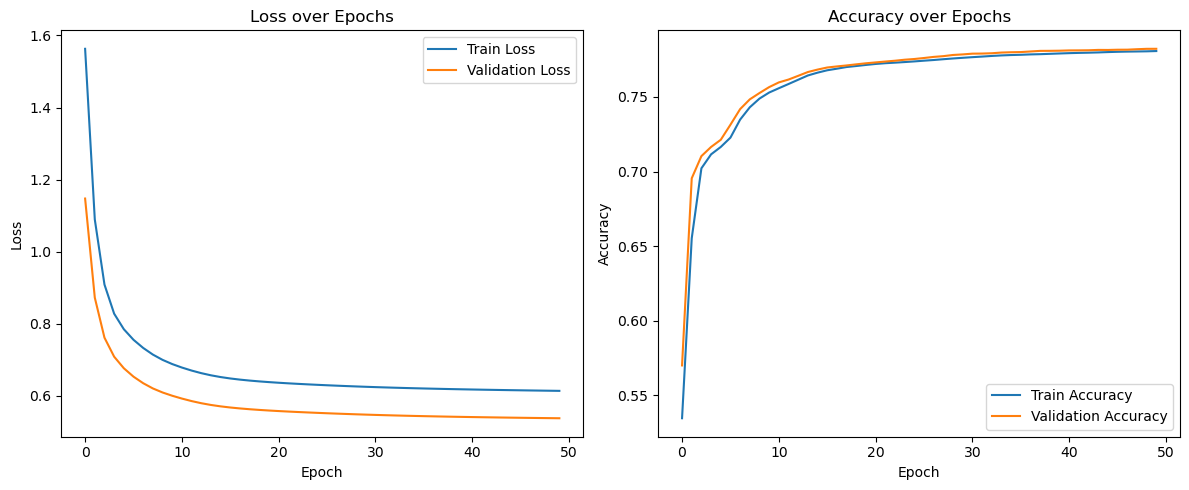

Model loaded from models/SoftDecisionTree_covertype.pt


In [35]:
## Train
# model_softdt.train(softdt,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")
## Load
softdt = model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

In [36]:
model_softdt.test(softdt, (X_test, y_test), config["device"])

Accuracy: 78.05%


#### Tab Transformer

In [25]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "covertype",
    "epochs": 30,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=categories,
                                         num_continuous=continues_num,
                                         dim=trans_dim,
                                         depth=4,
                                         heads=5,
                                         dim_head=10,
                                         dim_out=7,
                                         attn_dropout=0.1,
                                         ff_dropout=0.1,
                                         )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-2, weight_decay=1e-4)

Training TabTransformer on covertype...


Epoch 29: 100%|██████████| 30/30 [01:47<00:00,  3.59s/epoch, train_loss=0.281, train_accuracy=0.885, val_loss=0.284, val_accuracy=0.886]


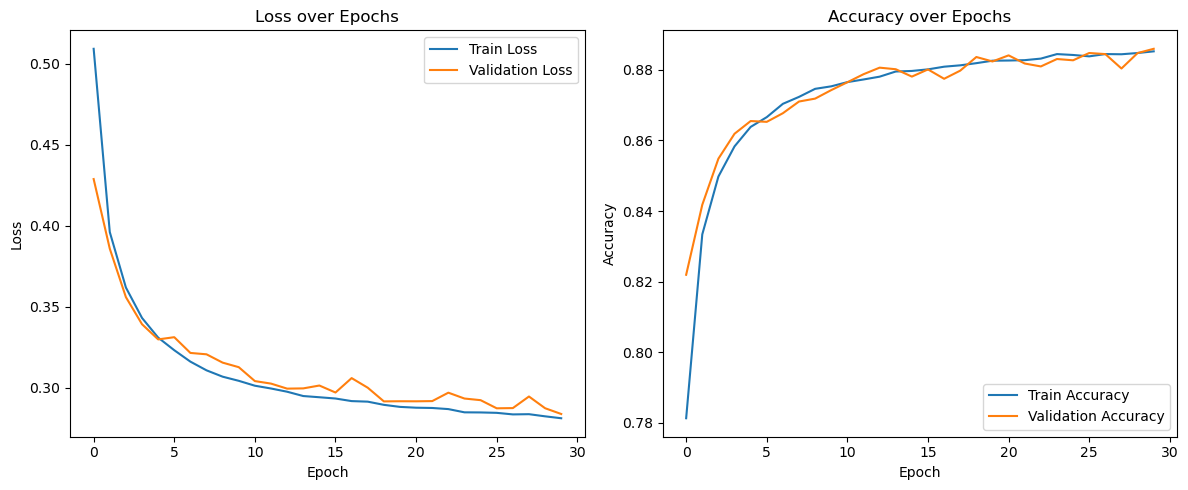

Model loaded from models/TabTransformer_covertype.pt


In [26]:
## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

In [27]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])

Accuracy: 88.53%
